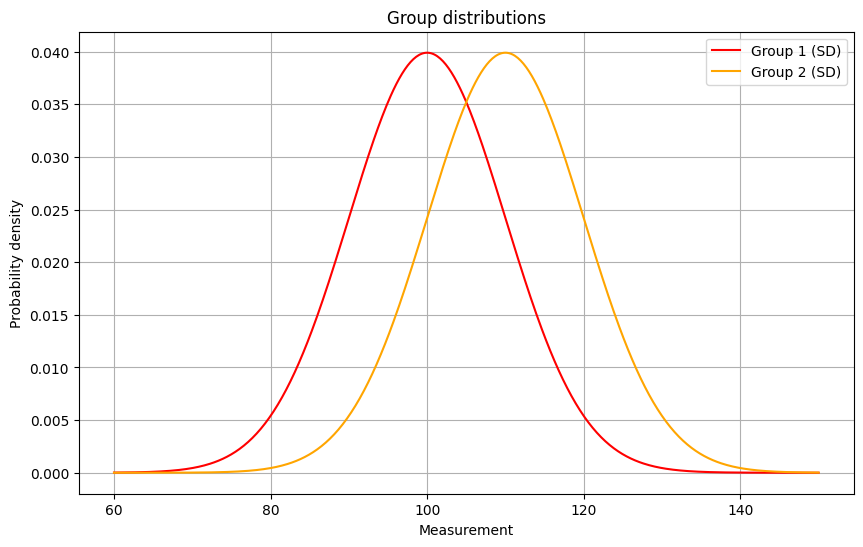

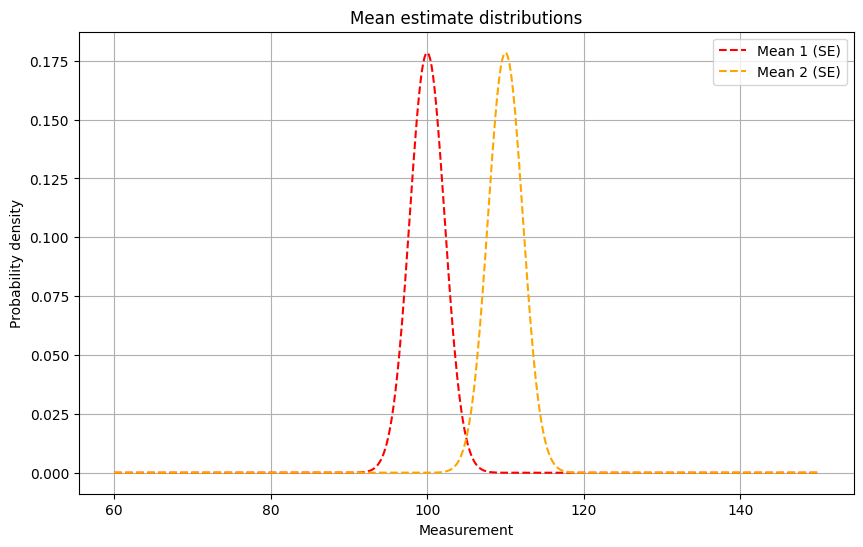

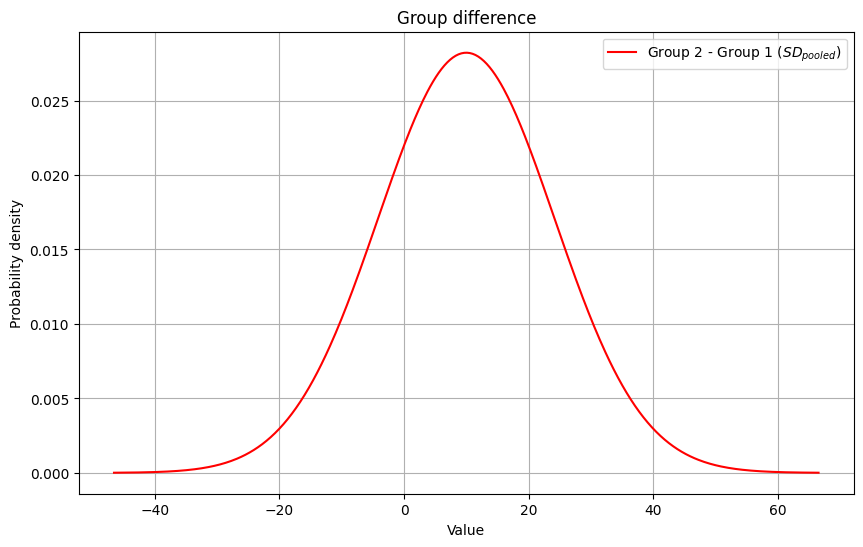

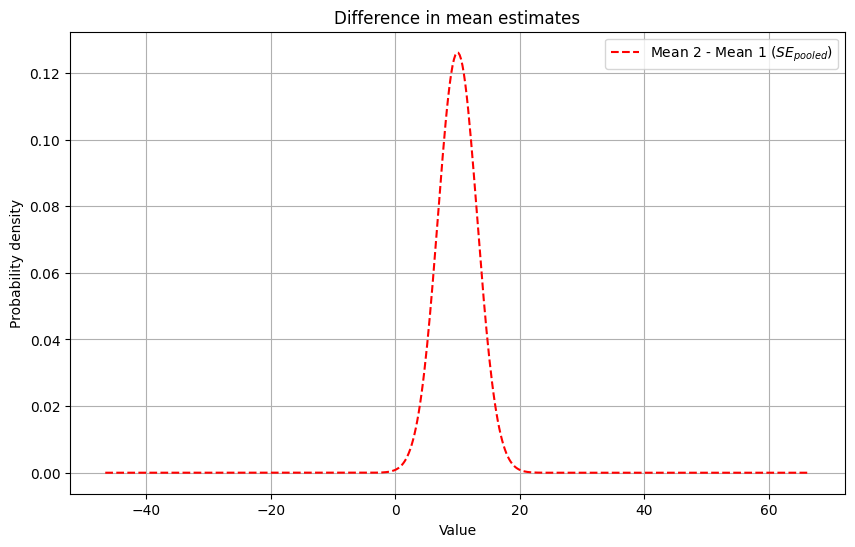

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
n = 20               # sample size per group
sd = 10              # SD of individual measurements
mean1, mean2 = 100, 110  # group means

# X-axis for plotting
x = np.linspace(mean1 - 4*sd, mean2 + 4*sd, 500)

# Distributions of individual measurements (group-level)
dist_group1 = norm.pdf(x, loc=mean1, scale=sd)
dist_group2 = norm.pdf(x, loc=mean2, scale=sd)

# Standard errors of the means
se = sd / np.sqrt(n)

# Distributions of mean estimates
dist_mean1 = norm.pdf(x, loc=mean1, scale=se)
dist_mean2 = norm.pdf(x, loc=mean2, scale=se)


#############
# Plot
#############

# Raw group distributions
plt.figure(figsize=(10,6))
plt.plot(x, dist_group1, color='red', linestyle='-', label='Group 1 (SD)')
plt.plot(x, dist_group2, color='orange', linestyle='-', label='Group 2 (SD)')
plt.title('Group distributions')
plt.xlabel('Measurement')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()

# Distributions of mean estimates
plt.figure(figsize=(10,6))
plt.plot(x, dist_mean1, color='red', linestyle='--', label='Mean 1 (SE)')
plt.plot(x, dist_mean2, color='orange', linestyle='--', label='Mean 2 (SE)')
plt.title('Mean estimate distributions')
plt.xlabel('Measurement')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()



# Calculate the distribution of the group differences
group_diff = mean2 - mean1
group_sd = np.sqrt(sd**2 + sd**2)


# Calculate the distribution of the differences in mean estimates
mean_diff = mean2 - mean1
mean_se = np.sqrt(se**2 + se**2)

# X-axis for plotting
x_diff = np.linspace(group_diff-4*group_sd, group_diff+4*group_sd, 500)

# Distributions
mean_diff_dist = norm.pdf(x_diff, loc=mean_diff, scale=mean_se)
group_diff_dist = norm.pdf(x_diff, loc=group_diff, scale=group_sd)


#############
# Plot
#############

# Distribution of group difference
plt.figure(figsize=(10,6))
plt.plot(x_diff, group_diff_dist, color='red', linestyle='-', label='Group 2 - Group 1 $(SD_{pooled})$')
plt.title('Group difference')
plt.xlabel('Value')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()

# Distribution of difference in mean estimates
plt.figure(figsize=(10,6))
plt.plot(x_diff, mean_diff_dist, color='red', linestyle='--', label='Mean 2 - Mean 1 $(SE_{pooled})$')
plt.title('Difference in mean estimates')
plt.xlabel('Value')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()

Power of difference in group distributions : 16.849593622500493 %


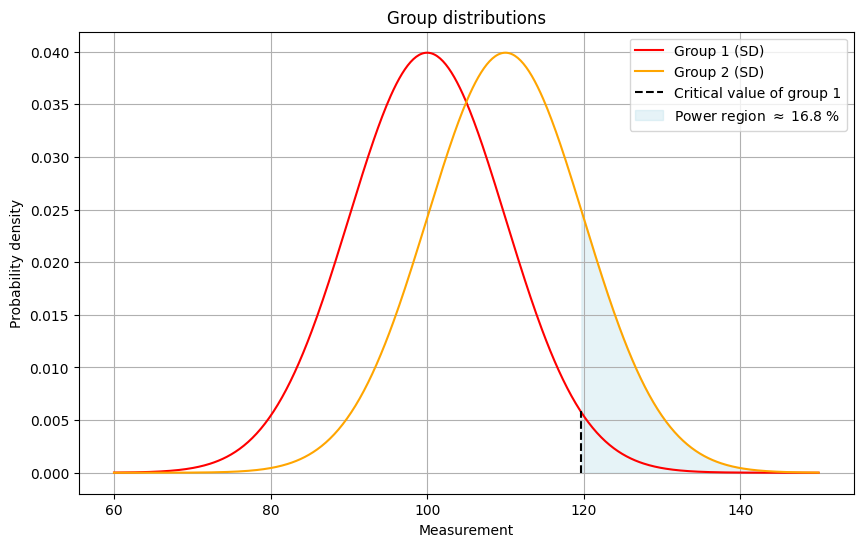

In [167]:

# Calculate power of the difference in group distributions and visualize at two-sided alpha = 0.05

x1 = mean1 + 1.96*sd
x2 = mean2 + 4*sd

group2_power = norm.cdf(x2, loc=mean2, scale=sd) - norm.cdf(x1, loc=mean2, scale=sd)

print("Power of difference in group distributions :", 100*group2_power, "%")

#############
# Plot
#############

# Fill the area under group2 curve between x1 and x2
mask = (x >= x1) & (x <= x2)
y_line = norm.pdf(x1, loc=mean1, scale=sd)

# Power of differece in group distirbutions
plt.figure(figsize=(10,6))
plt.plot(x, dist_group1, color='red', linestyle='-', label='Group 1 (SD)')
plt.plot(x, dist_group2, color='orange', linestyle='-', label='Group 2 (SD)')
plt.plot([x1, x1], [0, y_line], color='black', linestyle='--', label=f'Critical value of group 1')
plt.fill_between(x[mask], 0, dist_group2[mask], color='lightblue', alpha=0.3, label=rf'Power region $\approx$ {100 * group2_power:.1f} %')
plt.title('Group distributions')
plt.xlabel('Measurement')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()

Power of difference in mean estimates : 99.39681863928101 %


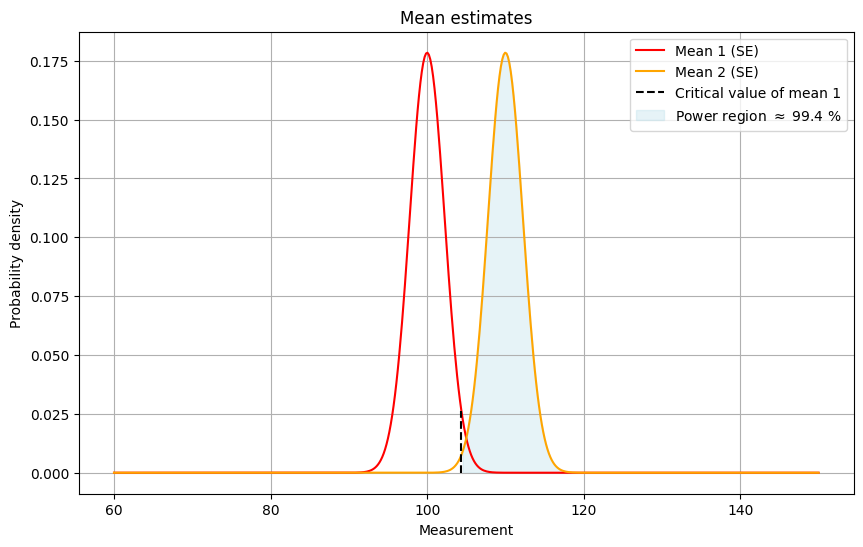

In [166]:
# Calculate power of the difference in mean estimates and visualize at two-sided alpha = 0.05

x1 = mean1 + 1.96*se
x2 = mean2 + 4*se

mean2_power = norm.cdf(x2, loc=mean2, scale=se) - norm.cdf(x1, loc=mean2, scale=se)

print("Power of difference in mean estimates :", 100*mean2_power, "%")

#############
# Plot
#############

# Fill the area under group2 curve between x1 and x2
mask = (x >= x1) & (x <= x2)
y_line = norm.pdf(x1, loc=mean1, scale=se)

# Power of differece in mean estimates
plt.figure(figsize=(10,6))
plt.plot(x, dist_mean1, color='red', linestyle='-', label='Mean 1 (SE)')
plt.plot(x, dist_mean2, color='orange', linestyle='-', label='Mean 2 (SE)')
plt.plot([x1, x1], [0, y_line], color='black', linestyle='--', label=f'Critical value of mean 1')
plt.fill_between(x[mask], 0, dist_mean2[mask], color='lightblue', alpha=0.3, label=rf'Power region $\approx$ {100 * mean2_power:.1f} %')
plt.title('Mean estimates')
plt.xlabel('Measurement')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion:
### There can be a statistically powerful and significant difference in the estimated means between two groups, while the actual group differences accounting for group variability are meaningless in practice.